In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
%matplotlib inline
import numpy as np
import matplotlib.dates as mdates
from scipy.io import loadmat
import xarray as xr
import pandas as pd
import os
import sys
from scipy.stats import pearsonr
from datetime import datetime
%load_ext autoreload
%autoreload 2
import os, sys
sys.path.append(os.getcwd())
os.chdir("../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")
ds = xr.open_dataset(path+"adcp_data_and_analysis_lars_smedsrud/Nortek_ADCP_currents_Oct20_to_Nov4_tide_shifted.nc")
# camp 2021 coordinates
lon = 166.23333333333332
lat = -77.86666666666666
residual_current = ds.v - ds.tide_v
ds = ds.assign(residual_current=("time", residual_current.data))

In [2]:
# generate correlation lags of one day
# how many indices in one day?
# round datetime64 to days
time_rounded = ds.time.data.astype("datetime64[D]")
# where difference t(i)-t(i-1)>0 = index of day change
dtime_rounded = time_rounded[1:]-time_rounded[0:-1]
day_index = np.concatenate((np.array([0]),np.where(dtime_rounded.astype("int")>0)[0]))
dday_index = day_index[1:]-day_index[0:-1]
# time of correlation
corrtime = ds.time.data[day_index[0:-1]] + (ds.time.data[day_index[1:]]-ds.time.data[day_index[0:-1]])/2
corrcoef = {}
pvalue   = {}

for param in ["v", "tide_v"]:
    nblocks = len(day_index) - 1
    corrcoef[param] = np.full(nblocks, np.nan)
    pvalue[param]   = np.full(nblocks, np.nan)

    for i in range(nblocks):
        s = (ds
             .sel(depth_profile=slice(14.5, 15.5))
             .sel(time=slice(ds.time[day_index[i]], ds.time[day_index[i+1]])))

        # Extract 1-D vectors; squeeze to avoid shapes like (1, 74)
        x = np.squeeze(s["amplitude"].data)
        y = np.squeeze(s[param].data)   # <-- requires that ds has a variable named exactly 'v' or 'tide_v'

        # Pairwise finite mask
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if x.ndim != 1: x = np.ravel(x)
        if y.ndim != 1: y = np.ravel(y)

        if x.size >= 2 and y.size >= 2 and x.size == y.size:
            corrcoef[param][i], pvalue[param][i] = pearsonr(x, y)
        else:
            corrcoef[param][i] = np.nan
            pvalue[param][i]   = np.nan

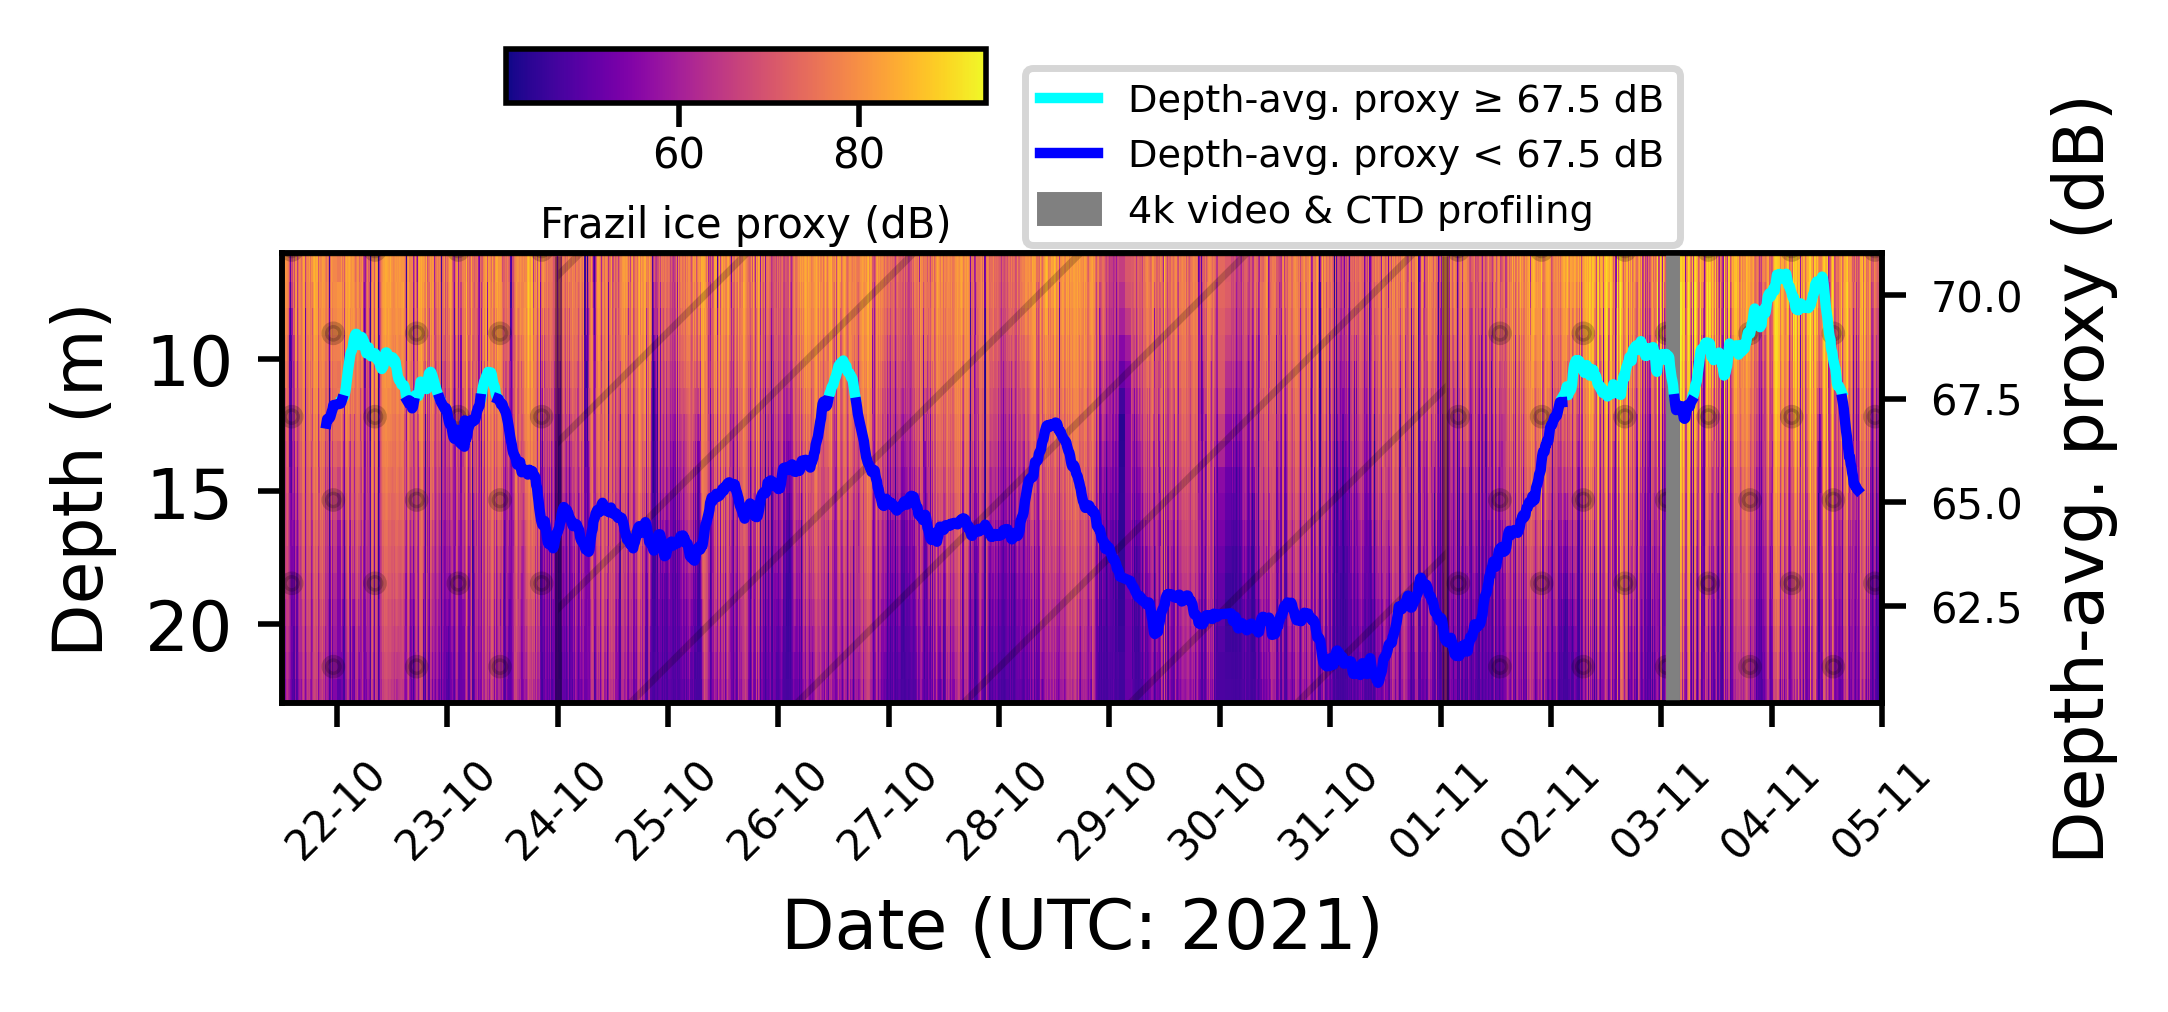

In [3]:
# --- Figure & axes layout using Divider ---
fig = plt.figure(figsize=(4, 1.5), dpi=500)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)

# Main image axis
ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))

# --- Select image data (AZFP vs ADCP) ---
try:  # AZFP
    plot_image = ds.SvArrays[:, :, 1]
except Exception:  # ADCP
    plot_image = ds.BSv

# --- Plot the image ---
im = plot_image.plot(
    ax=ax, yincrease=False, add_colorbar=False, cmap=plt.cm.plasma, zorder=0
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("Depth (m)")

# --- X-axis: dates ---
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.tick_params(axis="x", labelrotation=45, labelsize=6)

# Limits
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")
ax.set_ylim([23, 6])  # inverted depth (surface at top)

# --- Secondary y-axis for depth-averaged BSv ---
# --- Secondary y-axis for depth-averaged BSv ---
ax2 = ax.twinx()

ds["BSv"] = ds.BSv.where(np.isfinite(ds.BSv), np.nan)
window_size = 128
depth_averaged_BSv = (
    ds.BSv.mean(dim="depth_profile", skipna=True)
      .rolling(time=window_size, center=True)
      .mean()
)

# Threshold
thr = 67.5

# Split into two masked series so lines break at threshold crossings
below_thr = depth_averaged_BSv.where(depth_averaged_BSv < thr)
above_thr = depth_averaged_BSv.where(depth_averaged_BSv >= thr)

# Plot above-threshold (cyan) and below-threshold (blue)
line_above, = ax2.plot(
    above_thr.time, above_thr,
    color='cyan', linestyle='-', marker='', zorder=10,
    label='Depth-avg. proxy ≥ 67.5 dB'
)
line_below, = ax2.plot(
    below_thr.time, below_thr,
    color='blue', linestyle='-', marker='', zorder=10,
    label='Depth-avg. proxy < 67.5 dB'
)

# Right y-axis styling (neutral color since line colors are mixed)
ax2.set_ylabel("Depth-avg. proxy (dB)", color='black')
ax2.tick_params(axis="y", labelcolor='black', labelsize=6)

# Update legend handles to include both lines
handles, labels = ax2.get_legend_handles_labels()

span = ax2.axvspan(
    pd.to_datetime("2021-11-03 01:42:54.650715136"),
    pd.to_datetime("2021-11-03 03:13:24.248978936"),
    color="grey", alpha=1, label="4k video & CTD profiling"
)

# Indicate neap/spring tide windows
ax.axvspan(np.datetime64("2021-10-21T01:00"), np.datetime64("2021-10-24T00:00"),
           facecolor='none', edgecolor='black', hatch='.', alpha=0.2)
ax.axvspan(np.datetime64("2021-10-24T00:00"), np.datetime64("2021-11-01T01:00"),
           facecolor='none', edgecolor='black', hatch='/', alpha=0.2)
ax.axvspan(np.datetime64("2021-11-01T01:00"), np.datetime64("2021-11-05T01:00"),
           facecolor='none', edgecolor='black', hatch='.', alpha=0.2)

plt.rcParams.update({'font.size': 6})

# ==============================
# TOP COLORBAR: 30% of axis width, ABOVE the plot
# ==============================
# 1) Draw once to get accurate axis bbox in *figure* coordinates
fig.canvas.draw()
ax_pos = ax.get_position()  # Bbox: x0, y0, x1, y1 in figure coords

# 2) Compute colorbar axis rect above ax
cb_width  = 0.30 * ax_pos.width           # 30% of the main axis width
cb_height = 0.12 * ax_pos.height          # ~12% of the axis height (tweak if needed)
gap       = 0.2                         # vertical gap between plot and colorbar (in fig coords)

cb_x0 = ax_pos.x0 + (ax_pos.width - cb_width) / 5.0   # center horizontally over ax
cb_y0 = ax_pos.y1 + gap                               # place just above the plot

# Create colorbar axis above the plot
cax = fig.add_axes([cb_x0, cb_y0, cb_width, cb_height])
c = fig.colorbar(im, cax=cax, orientation="horizontal")
c.set_label(r"Frazil ice proxy (dB)", rotation=0)
c.ax.tick_params(labelsize=6, pad=1.0)

# Optional aesthetics
# c.outline.set_visible(False)  # remove box outline if you prefer a clean bar

# ==============================
# LEGEND next to the colorbar
# ==============================
handles, labels = ax2.get_legend_handles_labels()

fig.canvas.draw()  # ensure cax position is final
cb_pos = cax.get_position()

legend_x = cb_pos.x1 + 0.01   # a small horizontal pad to the right of the colorbar
legend_y = cb_pos.y1
fig.legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(legend_x, legend_y),
    ncol=1,
    fontsize=5.5,
    frameon=True,
    handlelength=1.5,
)

# Save
# fig.savefig(os.path.join(save_dir, "backscatter.png"), dpi=500, bbox_inches="tight")
# plt.show()


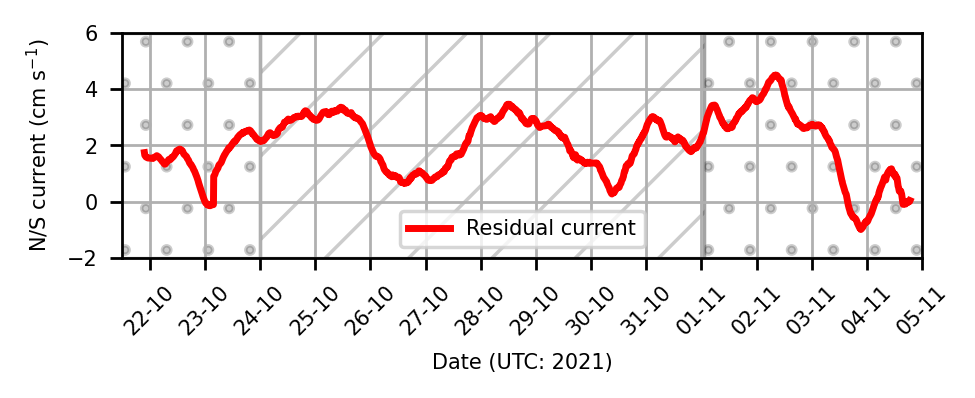

In [4]:
# Apply a rolling mean to smooth the residuals
window_size = 128  # Number of time steps in the rolling window
smoothed_current = (residual_current).rolling(time=window_size, center=True).mean()
# smoothed_current = smoothed_current.resample(time="1D", loffset="12H").mean()

fig = plt.figure(figsize=(4, 1.5), dpi=250)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
time_window = window_size*(smoothed_current.time[1].data-smoothed_current.time[0].data)
# Plot original and smoothed current
# ax.plot(ds.time, ds.v - ds.tide_v, label="Original", alpha=0.5)
ax.plot(smoothed_current.time, smoothed_current, label="Residual current", 
        color="red", 
        linewidth=2)

# indicate neap tide
ax.axvspan(np.datetime64("2021-10-21T01:00"), np.datetime64("2021-10-24T00:00"), 
           facecolor='none', edgecolor='black', hatch='.',  alpha=0.2)
ax.axvspan(np.datetime64("2021-10-24T00:00"),np.datetime64("2021-11-01T01:00") , 
           facecolor='none', edgecolor='black', hatch='/', alpha=0.2)
ax.axvspan(np.datetime64("2021-11-01T01:00"), np.datetime64("2021-11-05T01:00"), 
           facecolor='none', edgecolor='black', hatch='.', alpha=0.2)

# Customize plot
ylabel = r"N/S current (cm s$^{-1}$)"
ax.set_ylabel(ylabel)
ax.xaxis.grid()
ax.yaxis.grid()
ax.set_ylim([-2, 6])
# ax.set_title("Residual current")

# Set date format to dd-mm
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")

ax.legend(loc="best")
plt.rcParams.update({'font.size': 7})
plt.show()
# fig.tight_layout()
# fig.savefig(os.path.join(save_dir, "residual_current.png"), dpi=300, bbox_inches="tight")

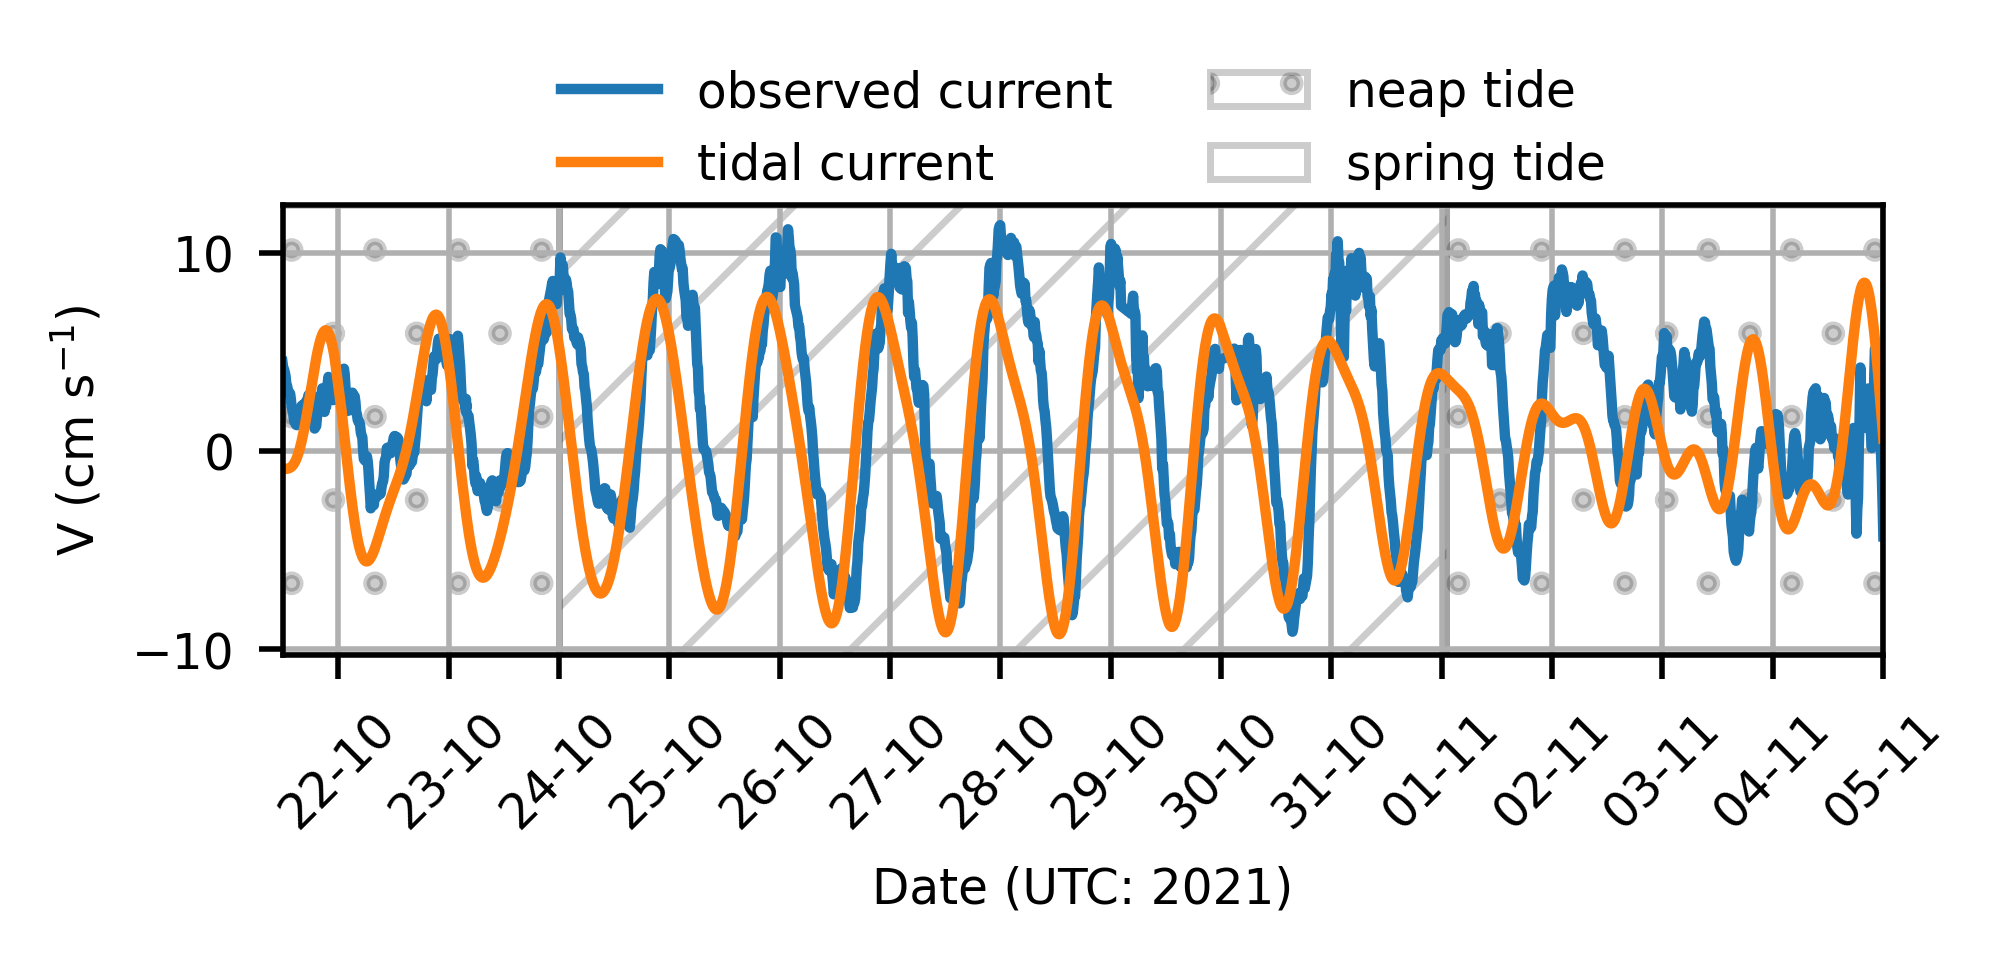

In [5]:
ds = xr.open_dataset(path+"adcp_data_and_analysis_lars_smedsrud/Nortek_ADCP_currents_Oct20_to_Nov4_avgd_cal.nc")
# smooth the current to take out noise
window_size = 5  # Number of time steps in the rolling window
smoothed_current_2 = ds.v.rolling(time=window_size, center=True).mean()

fig = plt.figure(figsize=(4, 1.5), dpi=500)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.

ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
# fig.tight_layout()
# current plot
smoothed_current_2.plot(ax=ax, label="observed current")
ds.tide_v.plot(ax=ax, label="tidal current")

# indicate neap tide
ax.axvspan(np.datetime64("2021-10-21T01:00"), np.datetime64("2021-10-24T00:00"), 
           facecolor='none', edgecolor='black', hatch='.', label="neap tide", alpha=0.2)
ax.axvspan(np.datetime64("2021-10-24T00:00"),np.datetime64("2021-11-01T01:00") , 
           facecolor='none', edgecolor='black', hatch='/', label="spring tide", alpha=0.2)
ax.axvspan(np.datetime64("2021-11-01T01:00"), np.datetime64("2021-11-05T01:00"), 
           facecolor='none', edgecolor='black', hatch='.', alpha=0.2)

# # residual current plot
# ax.plot(smoothed_current.time, smoothed_current, label="Residual current", 
#         color="tab:green", 
#         linewidth=2)

ylabel = r"V (cm s$^{-1}$)"
ax.set_ylabel(ylabel)
# set grid
ax.xaxis.grid()
ax.yaxis.grid()

# Set date format to dd-mm
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)

# Set the interval to one day
ax.xaxis.set_major_locator(mdates.DayLocator())

# Rotate tick labels for better readability
plt.xticks(rotation=45)
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=2, frameon=False)
# plt.margins(x=0)
plt.rcParams.update({'font.size': 7})
# fig.savefig(save_dir+"currents.png", dpi=500, bbox_inches='tight')

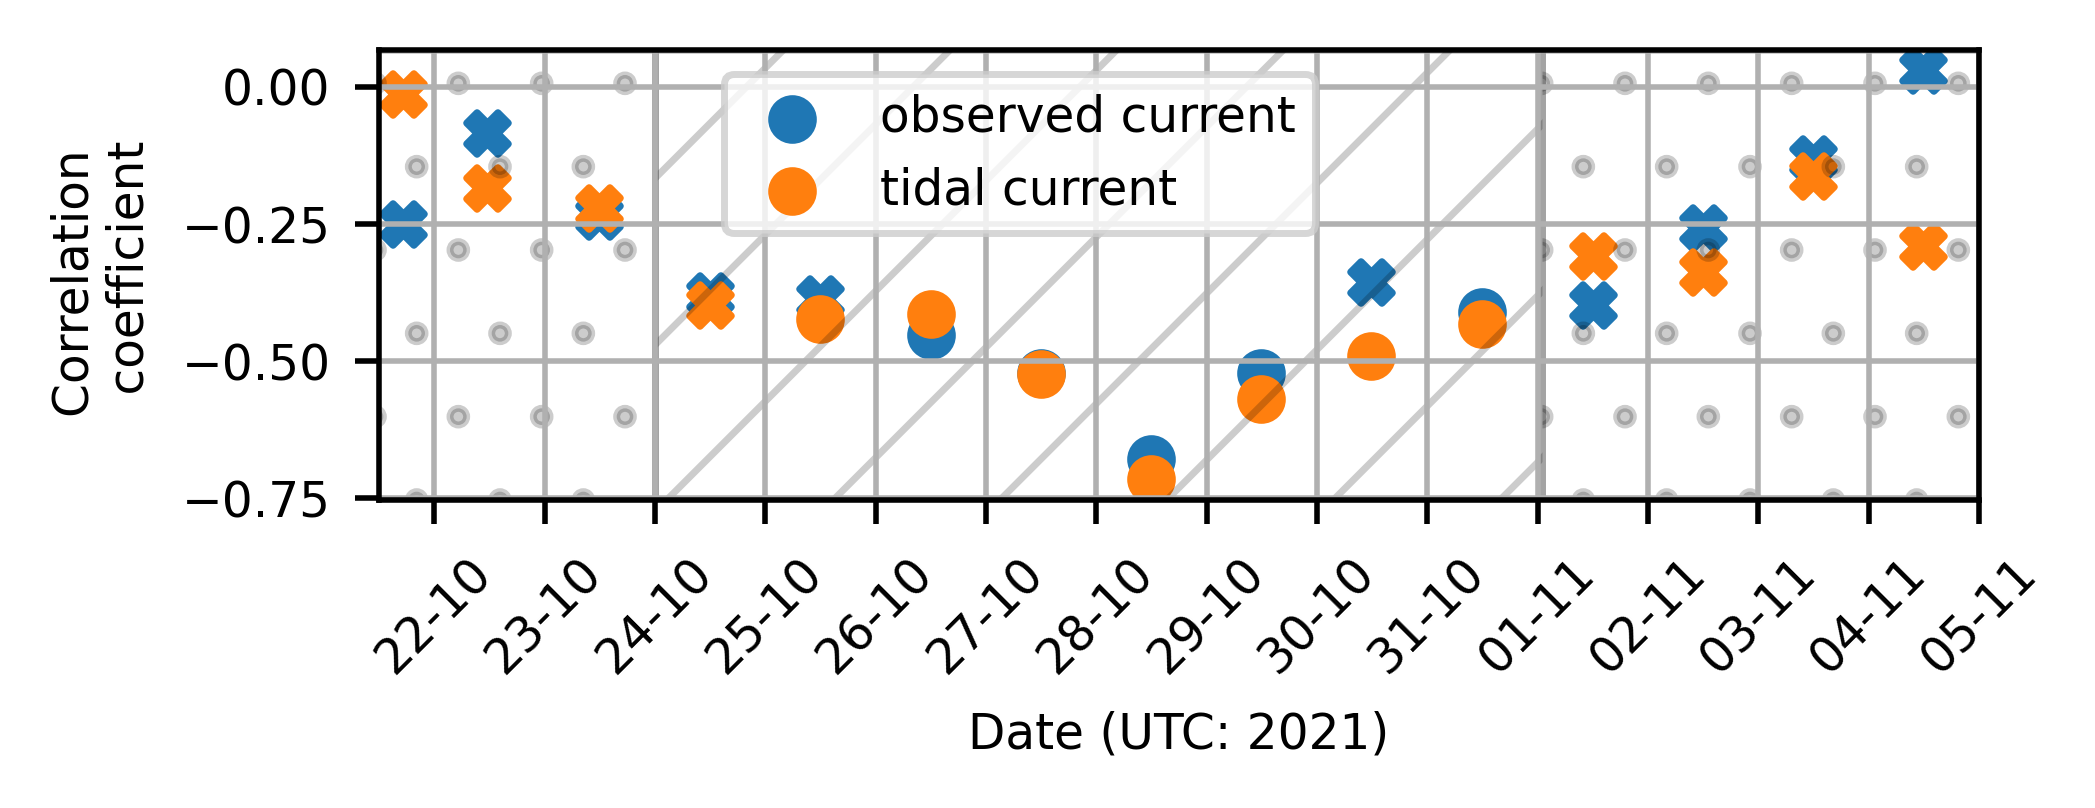

In [6]:
fig = plt.figure(figsize=(4, 1.5), dpi=500)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.

ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
# fig.tight_layout()
# correlation plot
ax.scatter(corrtime[abs(corrcoef["v"])>0.4], corrcoef["v"][abs(corrcoef["v"])>0.4], label="observed current", color="tab:blue")
ax.scatter(corrtime[abs(corrcoef["v"])<0.4], corrcoef["v"][abs(corrcoef["v"])<0.4], color="tab:blue",
          marker='X')
# ax.scatter(corrtime[abs(corrcoef["residual_current"])>0.4], corrcoef["residual_current"][abs(corrcoef["residual_current"])>0.4],\
#            label="residual current", color="tab:green")
# ax.scatter(corrtime[abs(corrcoef["residual_current"])<0.4], corrcoef["residual_current"][abs(corrcoef["residual_current"])<0.4], color="tab:green",
#           marker='X')
ax.scatter(corrtime[abs(corrcoef["tide_v"])>0.4], corrcoef["tide_v"][abs(corrcoef["tide_v"])>0.4],
           label="tidal current", color="tab:orange")
ax.scatter(corrtime[abs(corrcoef["tide_v"])<0.4], corrcoef["tide_v"][abs(corrcoef["tide_v"])<0.4],
             color="tab:orange", marker="X")
# ax.scatter(corrtime, corrcoef["temperature"], label="temperature")
ax.set_ylabel("Correlation \n coefficient")
ax.xaxis.grid()
ax.yaxis.grid()
ax.set_title("")
ax.legend(loc="upper right",  # Choose the location within the axes
    bbox_to_anchor=(0.6,1.)  # Adjust position within the plot area
         )

# indicate neap tide
ax.axvspan(np.datetime64("2021-10-21T01:00"), np.datetime64("2021-10-24T00:00"), 
           facecolor='none', edgecolor='black', hatch='.', label="neap tide", alpha=0.2)
ax.axvspan(np.datetime64("2021-10-24T00:00"),np.datetime64("2021-11-01T01:00") , 
           facecolor='none', edgecolor='black', hatch='/', label="spring tide", alpha=0.2)
ax.axvspan(np.datetime64("2021-11-01T01:00"), np.datetime64("2021-11-05T01:00"), 
           facecolor='none', edgecolor='black', hatch='.', alpha=0.2)

# Set date format to dd-mm
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)

# Set the interval to one day
ax.xaxis.set_major_locator(mdates.DayLocator())

# Rotate tick labels for better readability
plt.xticks(rotation=45)
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")

# ax.set_xlim([ds.time[0].data, ds.time[-1].data])
plt.rcParams.update({'font.size': 7})
# fig.savefig(save_dir+"correlations.png",bbox_inches='tight', dpi=500)

In [7]:
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})
print(pvalue["v"]*100)
print(pvalue["tide_v"]*100)

[3.168 32.380 0.131 0.000 0.000 0.000 0.000 0.000 0.000 0.003 0.000 0.000
 0.182 11.593 72.030]
[90.884 2.893 0.278 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.015
 0.003 4.968 0.038]


In [8]:
# integrate over the previous plot over negative currents / southward period
# choose the southward period
sel_current = smoothed_current.sel(time=slice(pd.to_datetime("28-10-2021T10:22"), pd.to_datetime("28-10-2021T18:32")))

dt = sel_current.time[1].data-sel_current.time[0].data
print(dt)
integrated_current = sel_current.sum().data*dt.item()/1e9/1e2
print("Eddy length from bathymetric features downstream ", integrated_current, " metres")

599999994000 nanoseconds
Eddy length from bathymetric features downstream  958.6586975623259  metres


/tmp/ipykernel_61739/3661859603.py:3: UserWarning: Parsing dates in %d-%m-%YT%H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sel_current = smoothed_current.sel(time=slice(pd.to_datetime("28-10-2021T10:22"), pd.to_datetime("28-10-2021T18:32")))


In [9]:
# Test hypothesis: frazil came from depth starting 1 Nov. Test with
# initiation of the non-steady state Holland and Feltham 2005 model simulation with frazil appearing at 23 m depth
# and stratification happening over a (13.6/2) days period with frazil accumulating beneath the sea ice at the end.

# Note: This hypothesis only applied to the in-situ supercooled layer, 
# while there was an interleaving watermass below with possibly more complicated frazil dynamics

# Broad check: apply 2 hourly smoothing and plot the backscatter ratio between 15m and 8m depth.
# Smooth backscatter and downsample for quicker visualization
# Example input
depth_sample_size = 8.  # meters
time_sample_size = pd.Timedelta(ds.time[1].data-ds.time[0].data)
time_downsample_interval = "1440min"  # Downsample interval

# Define moving average window sizes for depth and time
depth_window = int(depth_sample_size / depth_sample_size)  # Example: smoothing over 1m
time_window = int(pd.Timedelta(time_downsample_interval).total_seconds() / pd.Timedelta(time_sample_size).total_seconds())  # ~5min

# Moving average filter (rolling window)
smoothed_data = (
    ds["BSv"]
    .rolling(depth_profile=depth_window, time=time_window, center=True)  # Apply rolling
    .mean()
)

# Downsample the smoothed data to 11-minute intervals
smoothed_data_downsampled = smoothed_data.coarsen(time=11, boundary="trim").mean()

# Downsample the entire dataset
ds_downsampled = ds.coarsen(time=11, boundary="trim").mean()

# Add the smoothed data back to the downsampled dataset
ds_downsampled["Smoothed_SvArrays"] = smoothed_data_downsampled
# save
if os.path.exists(path+"azfp_xarray_downsampled.nc"):
    os.remove(path+"azfp_xarray_downsampled.nc")
ds_downsampled.to_netcdf(path+"downsampled.nc", engine="netcdf4")
# ds = ds_downsampled

/tmp/ipykernel_61739/3916392401.py:37: UserWarning: Times can't be serialized faithfully to int64 with requested units 'microseconds since 2021-10-21T11:01:18.062991'. Serializing with units 'nanoseconds since 2021-10-21T11:01:18.062991' instead. Set encoding['dtype'] to floating point dtype to serialize with units 'microseconds since 2021-10-21T11:01:18.062991'. Set encoding['units'] to 'nanoseconds since 2021-10-21T11:01:18.062991' to silence this warning .
  ds_downsampled.to_netcdf(path+"downsampled.nc", engine="netcdf4")


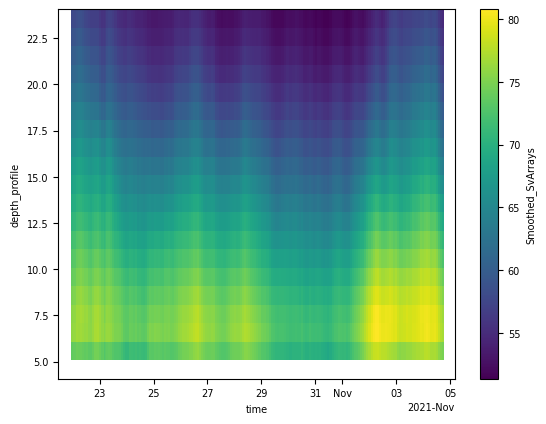

In [10]:
plt.figure()
ds_downsampled["Smoothed_SvArrays"].plot()